## Exercise:
- do initial EDA
- how many data jobs are there in the data set?
- how many work years are represented?
- which countries exists in this dataset?
- what type of company sizes are there
- ratio of remote work vs office
- average salaries per job role
- median salaries per job role
- seniority level and average salaries?
- remote work and average salaries?
- company location and average salaries?
- clean job titles
- do different visualizations
- export visualizations
- export cleaned data

In [141]:
import pandas as pd
df = pd.read_csv("salaries.csv")


In [142]:
# Do initial EDA
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
16529,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
16530,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
16531,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
16532,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [143]:
# initial EDA
df.info() # Non null? kolla Non-null och RangeIndex

<class 'pandas.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           16534 non-null  int64
 1   experience_level    16534 non-null  str  
 2   employment_type     16534 non-null  str  
 3   job_title           16534 non-null  str  
 4   salary              16534 non-null  int64
 5   salary_currency     16534 non-null  str  
 6   salary_in_usd       16534 non-null  int64
 7   employee_residence  16534 non-null  str  
 8   remote_ratio        16534 non-null  int64
 9   company_location    16534 non-null  str  
 10  company_size        16534 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.4 MB


In [144]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [145]:
## descriptive statistics of summative statistics
## only numerical columns used here
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,16534.000000,1.653400e+04,16534.000000,16534.000000
mean,2023.226866,1.637270e+05,149686.777973,32.003750
std,0.713558,3.402057e+05,68505.293156,46.245158
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.017630e+05,101125.000000,0.000000
50%,2023.000000,1.422000e+05,141300.000000,0.000000
75%,2024.000000,1.872000e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


In [146]:
df.describe().T # T stands for transpose: rows <-> columns

,count,mean,std,min,25%,50%,75%,max
work_year,16534.0,2023.226866,0.713558,2020.0,2023.0,2023.0,2024.0,2024.0
salary,16534.0,163726.962683,340205.744183,14000.0,101763.0,142200.0,187200.0,30400000.0
salary_in_usd,16534.0,149686.777973,68505.293156,15000.0,101125.0,141300.0,185900.0,800000.0
remote_ratio,16534.0,32.003750,46.245158,0.0,0.0,0.0,100.0,100.0


In [147]:
print(f"Rows: {df.shape[0]}, Cols: {df.shape[1]}")

Rows: 16534, Cols: 11


In [148]:
## What does a row represent? - an employee based on column empolyee_recidence
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


In [149]:
print(f"Number of employees in dataset: {len(df)}")

Number of employees in dataset: 16534


## Explore different categorical columns
- experience_level
- job_title
- employment_type
- employment_residence
- remote_ratio
- ...

In [150]:
df["experience_level"].value_counts() # kan se metadata(beskrivningar) i kaggle (eller där man hämtar datan) för att se tex vad förkortningarna står för

experience_level
SE    10670
MI     4038
EN     1325
EX      501
Name: count, dtype: int64

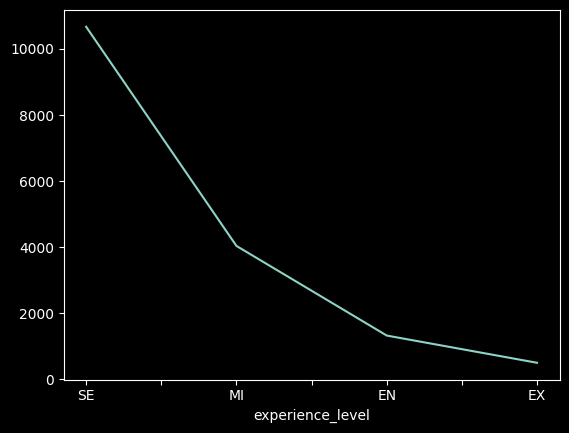

In [151]:
# don't do this!
df["experience_level"].value_counts().plot()

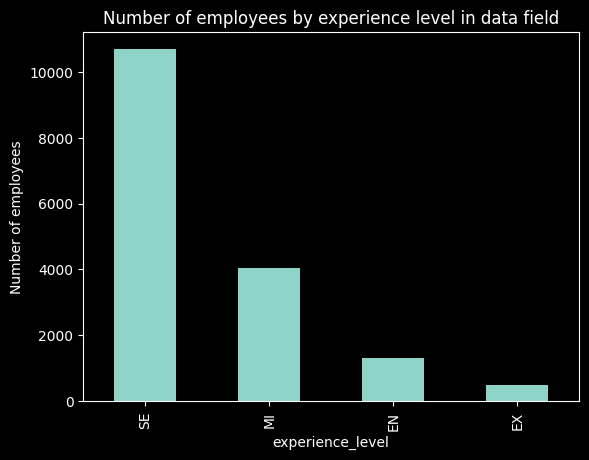

In [152]:
# Use barchart instead
#df["experience_level"].value_counts().plot.bar()

# .plot() wraps
ax = df["experience_level"].value_counts().plot(
    kind="bar",
    ylabel="Number of employees",
    title="Number of employees by experience level in data field",
)

In [163]:
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("employees_seniority_lvl.png", dpi=200)

In [154]:
# how many data jobs are in the dataset? - 155 st
df["job_title"].unique()

<StringArray>
[                      'AI Engineer',                     'Data Engineer',
         'Machine Learning Engineer',                       'ML Engineer',
                      'Data Analyst',                      'NLP Engineer',
                    'Data Scientist',                 'Applied Scientist',
                      'Data Manager',                    'Data Architect',
 ...
 'Computer Vision Software Engineer',           'Marketing Data Engineer',
            'Data Science Tech Lead',               'Data Scientist Lead',
            'Marketing Data Analyst',          'Principal Data Architect',
           'Data Analytics Engineer',              'Cloud Data Architect',
                'Lead Data Engineer',            'Principal Data Analyst']
Length: 155, dtype: str

In [155]:
import duckdb

duckdb.sql("""--sql
SELECT
DISTINCT(job_title)
FROM df
""")

┌──────────────────────────────────────┐
│              job_title               │
│               varchar                │
├──────────────────────────────────────┤
│ Data Manager                         │
│ Data Analytics Lead                  │
│ BI Developer                         │
│ Managing Director Data Science       │
│ Marketing Data Scientist             │
│ Machine Learning Modeler             │
│ Data Visualization Engineer          │
│ Analytics Engineering Manager        │
│ Business Intelligence Analyst        │
│ Machine Learning Operations Engineer │
│            ·                         │
│            ·                         │
│            ·                         │
│ Manager Data Management              │
│ Robotics Engineer                    │
│ Data Quality Engineer                │
│ Data DevOps Engineer                 │
│ ETL Engineer                         │
│ Data Integration Developer           │
│ Decision Scientist                   │
│ Data Visualiza

In [156]:
# how many work years are represented? - 5 st
df["work_year"].value_counts()

work_year
2023    8519
2024    6067
2022    1655
2021     218
2020      75
Name: count, dtype: int64

In [157]:
# which countries are represented in the dataset?
df["employee_residence"].value_counts()

employee_residence
US    14467
GB      686
CA      453
ES      137
DE       98
      ...  
IQ        1
BG        1
JE        1
RS        1
LU        1
Name: count, Length: 88, dtype: int64

In [158]:
# what type of company sizes are there
df["company_size"].value_counts()

company_size
M    15306
L     1040
S      188
Name: count, dtype: int64

In [159]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data%'
""").df()["job_title"].value_counts()

job_title
Data Engineer                    3464
Data Scientist                   3314
Data Analyst                     2440
Data Architect                    435
Data Science                      271
Data Manager                      212
Data Science Manager              122
Data Specialist                    86
Data Science Consultant            83
Data Analytics Manager             62
Data Modeler                       56
Data Product Manager               36
Data Developer                     30
Data Science Engineer              29
Data Lead                          26
Data Science Lead                  26
Data Operations Analyst            24
Data Quality Analyst               24
Data Strategist                    24
Data Integration Specialist        23
Data Analytics Lead                23
Data Management Analyst            22
Data Infrastructure Engineer       22
Data Integration Engineer          20
Data Science Practitioner          16
Data Operations Engineer           16
Da

In [160]:
# average salaries per job role
duckdb.sql("""--sql
    SELECT job_title,
    ROUND(AVG(salary)) as avarage_salary
    FROM df
    GROUP BY job_title
""")

┌─────────────────────────────┬────────────────┐
│          job_title          │ avarage_salary │
│           varchar           │     double     │
├─────────────────────────────┼────────────────┤
│ Data Science Practitioner   │       133650.0 │
│ BI Data Analyst             │       645526.0 │
│ Director of Data Science    │       214804.0 │
│ Principal Data Scientist    │       188200.0 │
│ AI Engineer                 │       163627.0 │
│ NLP Engineer                │       300041.0 │
│ Head of Data                │       208784.0 │
│ Manager Data Management     │      1562500.0 │
│ Robotics Engineer           │       140417.0 │
│ Data Quality Engineer       │       100000.0 │
│           ·                 │           ·    │
│           ·                 │           ·    │
│           ·                 │           ·    │
│ Machine Learning Researcher │       151157.0 │
│ Data Scientist Lead         │       134000.0 │
│ Research Engineer           │       207605.0 │
│ Bear Robotics     

In [161]:
# median salaries per job role
duckdb.sql("""--sql
    SELECT job_title,
    MEDIAN(salary) as median_salary
    FROM df
    GROUP BY job_title
""")

┌────────────────────────────────────┬───────────────┐
│             job_title              │ median_salary │
│              varchar               │    double     │
├────────────────────────────────────┼───────────────┤
│ Data Architect                     │      153000.0 │
│ Data Modeler                       │      130000.0 │
│ Director of Business Intelligence  │      187500.0 │
│ Data Product Owner                 │       88620.0 │
│ BI Analyst                         │      121900.0 │
│ Data Science Analyst               │       95000.0 │
│ ML Ops Engineer                    │      156400.0 │
│ Data Strategy Manager              │      107500.0 │
│ Marketing Data Analyst             │      137500.0 │
│ Data Engineer                      │      140000.0 │
│       ·                            │          ·    │
│       ·                            │          ·    │
│       ·                            │          ·    │
│ Business Intelligence Engineer     │      140000.0 │
│ Data Int

## Data cleaning
- similar titles put together

In [162]:
df["job_title"].value_counts().head(10)

job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
Applied Scientist             435
Data Architect                435
Analytics Engineer            431
Research Engineer             306
Data Science                  271
Name: count, dtype: int64

In [172]:
duckdb.sql("""--sql
    FROM df
    WHERE job_title ILIKE 'data scie%'
    """).df()["job_title"].value_counts()

job_title
Data Scientist               3314
Data Science                  271
Data Science Manager          122
Data Science Consultant        83
Data Science Engineer          29
Data Science Lead              26
Data Science Practitioner      16
Data Science Director           8
Data Science Analyst            4
Data Scientist Lead             2
Data Science Tech Lead          1
Name: count, dtype: int64

In [177]:
duckdb.sql("""--sql
    SELECT
        * EXCLUDE(job_title),
        CASE
            WHEN job_title ILIKE 'data scie%' THEN 'Data scientist'
            ELSE job_title
        END AS job_title
    FROM df
    """).df()["job_title"].value_counts()

job_title
Data scientist               3876
Data Engineer                3464
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
                             ... 
BI Data Engineer                1
Deep Learning Researcher        1
Marketing Data Engineer         1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 145, dtype: int64